# Car Price Prediction

Цель: построить модель, которая по характеристикам автомобиля
(год выпуска, пробег, тип топлива, мощность и т.д.)
предсказывает его цену `selling_price`.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Загрузка данных и первичный осмотр

- Загружаем датасет `car_data.csv`
- Смотрим размер, типы столбцов, наличие пропусков
- Целевая переменная: `selling_price`
- Признаки: пробег, год выпуска, тип топлива, тип коробки, владелец и т.д.

In [5]:
df = pd.read_csv('car_data.csv')

In [66]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [67]:
df.shape

(8128, 13)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [69]:
df.isnull().sum()
df = df.dropna().copy()
print(df[["mileage", "engine", "max_power", "torque"]].dtypes)

mileage      object
engine       object
max_power    object
torque       object
dtype: object


## 2. Очистка данных и приведение типов

- Преобразуем строковые признаки (`mileage` и т.п.) в числовые
- Кодируем `owner` в числовой формат
- Удаляем неинформативные или неудобные для модели столбцы (`name`)
- Проверяем, что типы данных корректны и пропусков либо нет, либо они обработаны

In [70]:

df["mileage"] = df["mileage"].str.extract(r'(\d+)').astype(float)
df["engine"] = df["engine"].str.extract(r'(\d+)').astype(float)
df["max_power"] = df["max_power"].str.extract(r'(\d+)').astype(float)
df["torque"] = df["torque"].str.extract(r'(\d+)').astype(float)
df["owner"] = df["owner"].str.split().str[0]

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7906 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           7906 non-null   object 
 1   year           7906 non-null   int64  
 2   selling_price  7906 non-null   int64  
 3   km_driven      7906 non-null   int64  
 4   fuel           7906 non-null   object 
 5   seller_type    7906 non-null   object 
 6   transmission   7906 non-null   object 
 7   owner          7906 non-null   object 
 8   mileage        7906 non-null   float64
 9   engine         7906 non-null   float64
 10  max_power      7906 non-null   float64
 11  torque         7906 non-null   float64
 12  seats          7906 non-null   float64
dtypes: float64(5), int64(3), object(5)
memory usage: 864.7+ KB


In [72]:
df["owner"].unique()

array(['First', 'Second', 'Third', 'Fourth', 'Test'], dtype=object)

In [73]:
df["owner"] = df["owner"].map({"First": 1, "Second": 2, "Third": 3, "Fourth": 4 ,"Test": 0})

In [74]:
df["owner"].unique()

array([1, 2, 3, 4, 0])

In [75]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

In [76]:
df = df.drop(columns=["name"]).copy()

In [77]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,2014,450000,145500,Diesel,Individual,Manual,1,23.0,1248.0,74.0,190.0,5.0
1,2014,370000,120000,Diesel,Individual,Manual,2,21.0,1498.0,103.0,250.0,5.0
2,2006,158000,140000,Petrol,Individual,Manual,3,17.0,1497.0,78.0,12.0,5.0
3,2010,225000,127000,Diesel,Individual,Manual,1,23.0,1396.0,90.0,22.0,5.0
4,2007,130000,120000,Petrol,Individual,Manual,1,16.0,1298.0,88.0,11.0,5.0


## 3. Feature engineering

Добавляем новые признаки

Идея: сделать признаки более "удобными" для модели и помочь ей
лучше улавливать нелинейные зависимости.

In [79]:
df["car_age"] = 2025 - df["year"]
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,car_age
0,2014,450000,145500,Diesel,Individual,Manual,1,23.0,1248.0,74.0,190.0,5.0,11
1,2014,370000,120000,Diesel,Individual,Manual,2,21.0,1498.0,103.0,250.0,5.0,11
2,2006,158000,140000,Petrol,Individual,Manual,3,17.0,1497.0,78.0,12.0,5.0,19
3,2010,225000,127000,Diesel,Individual,Manual,1,23.0,1396.0,90.0,22.0,5.0,15
4,2007,130000,120000,Petrol,Individual,Manual,1,16.0,1298.0,88.0,11.0,5.0,18


In [81]:
df["km_driven_log"] = np.log1p(df["km_driven"])
df["engine_per_km"] = df["engine"] / (df["km_driven"] + 1)
df["mileage_engine_ratio"] = df["mileage"] / df["engine"]
df["torque_power_ratio"] = df["torque"] / df["max_power"]

In [83]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,car_age,km_driven_log,engine_per_km,mileage_engine_ratio,torque_power_ratio
0,2014,450000,145500,Diesel,Individual,Manual,1,23.0,1248.0,74.0,190.0,5.0,11,11.887938,0.008577,0.018429,2.567568
1,2014,370000,120000,Diesel,Individual,Manual,2,21.0,1498.0,103.0,250.0,5.0,11,11.695255,0.012483,0.014019,2.427184
2,2006,158000,140000,Petrol,Individual,Manual,3,17.0,1497.0,78.0,12.0,5.0,19,11.849405,0.010693,0.011356,0.153846
3,2010,225000,127000,Diesel,Individual,Manual,1,23.0,1396.0,90.0,22.0,5.0,15,11.751950,0.010992,0.016476,0.244444
4,2007,130000,120000,Petrol,Individual,Manual,1,16.0,1298.0,88.0,11.0,5.0,18,11.695255,0.010817,0.012327,0.125000


In [84]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

num_cols = X.select_dtypes(include=["int64", "float64", "float32"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

In [85]:
num_cols

['year',
 'km_driven',
 'owner',
 'mileage',
 'engine',
 'max_power',
 'torque',
 'seats',
 'car_age',
 'km_driven_log',
 'engine_per_km',
 'mileage_engine_ratio',
 'torque_power_ratio']

In [86]:
cat_cols

['fuel', 'seller_type', 'transmission']

## 5. Препроцессинг признаков

Используем `ColumnTransformer`, чтобы:

- для числовых признаков:
  - в линейных моделях — применять `StandardScaler`
  - в деревьях/бустингах — передавать "как есть"
- для категориальных:
  - применять `OneHotEncoder(handle_unknown="ignore")`

Таким образом, мы строим два пайплайна:
один для линейных моделей, второй — для ансамблей деревьев.

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [88]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True  # shuffle по умолчанию и так True, можно не писать
)

## 6. Базовые линейные модели

Начинаем с простых моделей:

- `LinearRegression` — базовый линейный baseline
- `Ridge` — линейная модель с L2-регуляризацией

Для обеих моделей:
- обучаем пайплайн (препроцессинг + модель)
- считаем метрики (MAE, RMSE, R²)
- строим график "Predicted vs Actual"

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
linreg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("linear_regression", LinearRegression(
        fit_intercept=True,
        copy_X=True,
        n_jobs=None,
        positive=False
    ))
])

In [94]:
linreg.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('linear_regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [95]:
y_pred_linreg = linreg.predict(X_test)

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linreg)
mse = mean_squared_error(y_test, y_pred_linreg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linreg)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 265721.99226944585
RMSE: 436969.1762687386
R2: 0.7253750632849005


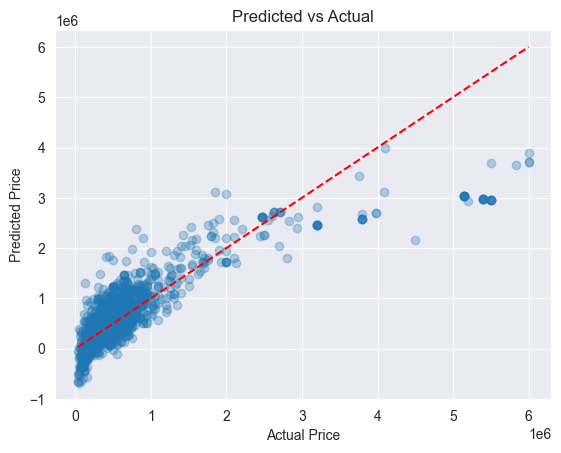

In [98]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_linreg, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [109]:
from sklearn.linear_model import Ridge
ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("ridge", Ridge(
        fit_intercept=True,
        copy_X=True,
        alpha= 1.0,
        max_iter=10000,
        solver="auto",
    ))
])

In [110]:
ridge.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [111]:
y_pred_ridge = ridge.predict(X_test)

In [112]:
mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 265651.72948515
RMSE: 436978.56201363937
R2: 0.725363265714631


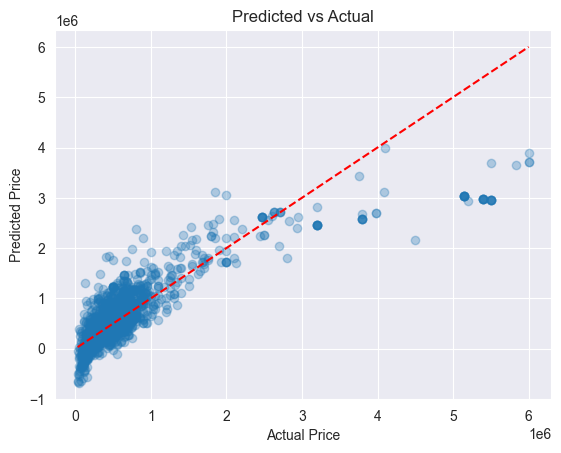

In [113]:
plt.scatter(y_test, y_pred_ridge, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [114]:
preprocessor2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

## 7. Деревья и бустинги

Пробуем более мощные модели, которые хорошо работают с табличными данными:

- `RandomForestRegressor` — ансамбль деревьев
- `XGBRegressor` — градиентный бустинг (XGBoost)
- `CatBoostRegressor` — бустинг с поддержкой категориальных признаков

Для каждой модели:
- собираем пайплайн (если нужно)
- обучаем на `X_train`, `y_train`
- считаем MAE, RMSE, R² на `X_test`, `y_test`
- строим график "Predicted vs Actual"

In [121]:
from sklearn.ensemble import RandomForestRegressor
rf = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("RandomForestRegressor", RandomForestRegressor(
        random_state=42,
        max_features="sqrt",
        n_estimators=400,
        bootstrap=True,
        criterion="squared_error",
        max_depth=12,
        min_samples_leaf=5,
        min_samples_split=3,
        n_jobs=-1
    ))
])

In [122]:
rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('RandomForestRegressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [123]:
y_pred_rf = rf.predict(X_test)

In [124]:
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 80939.1027464549
RMSE: 160041.99369957123
R2: 0.9631611325838957


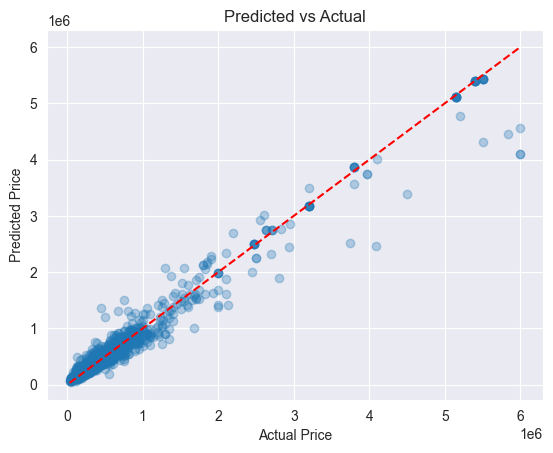

In [125]:
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [135]:
from xgboost import XGBRegressor
xgb = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("XGBRegressor", XGBRegressor(
    objective='reg:squarederror',
    n_estimators=600,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    min_child_weight=3,
    reg_lambda=1,
    reg_alpha=0,
    random_state=42
    ))
])

In [136]:
xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('XGBRegressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [137]:
y_pred_xgb = xgb.predict(X_test)

In [138]:
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 60496.30859375
RMSE: 107037.23524082635
R2: 0.9835218787193298


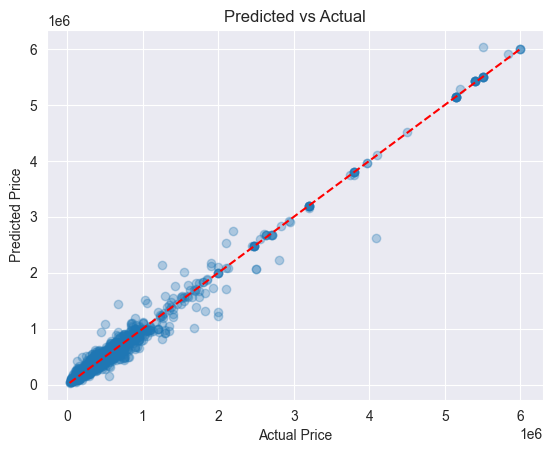

In [130]:
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [139]:
from catboost import CatBoostRegressor
cat = CatBoostRegressor(
    iterations=2000,
    depth=7,
    learning_rate=0.03,
    l2_leaf_reg=5,
    bagging_temperature=1,
    random_strength=1,
    loss_function="RMSE",
    random_state=42,
    verbose=200
)

In [141]:
cat.fit(X_train,
    y_train,
    cat_features=cat_cols,   # можно передать список имён колонок
    eval_set=(X_test, y_test),
    use_best_model=True)

0:	learn: 789116.6550271	test: 813960.1546507	best: 813960.1546507 (0)	total: 63.1ms	remaining: 2m 6s
200:	learn: 170167.7902295	test: 173679.0348838	best: 173679.0348838 (200)	total: 366ms	remaining: 3.28s
400:	learn: 142674.5975232	test: 152372.3709440	best: 152372.3709440 (400)	total: 641ms	remaining: 2.56s
600:	learn: 118805.7165614	test: 134854.6370943	best: 134843.9685032 (599)	total: 961ms	remaining: 2.24s
800:	learn: 108180.7419875	test: 128460.5408987	best: 128460.5408987 (800)	total: 1.29s	remaining: 1.94s
1000:	learn: 99665.6313161	test: 123198.7743358	best: 123198.7743358 (1000)	total: 1.62s	remaining: 1.62s
1200:	learn: 93140.6185232	test: 119162.7438882	best: 119162.7438882 (1200)	total: 1.95s	remaining: 1.3s
1400:	learn: 87846.2003312	test: 116361.0537356	best: 116361.0537356 (1400)	total: 2.29s	remaining: 979ms
1600:	learn: 83550.6106390	test: 114099.4976509	best: 114099.4976509 (1600)	total: 2.62s	remaining: 653ms
1800:	learn: 80386.5880547	test: 112643.6761275	best: 1

In [142]:
y_pred_cat = cat.predict(X_test)

In [143]:
mae = mean_absolute_error(y_test, y_pred_cat)
mse = mean_squared_error(y_test, y_pred_cat)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_cat)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 65476.34446580464
RMSE: 111754.21254956236
R2: 0.9820375253036974


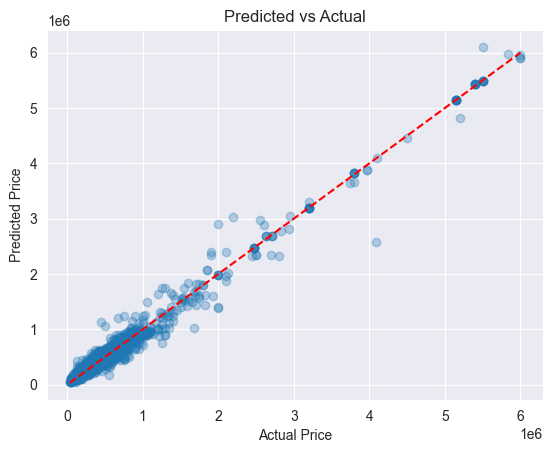

In [144]:
plt.scatter(y_test, y_pred_cat, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

## 8. Подбор гиперпараметров XGBoost с помощью Optuna

Используем Optuna для подбора гиперпараметров XGBoost:

- настраиваем:
  - `n_estimators`
  - `max_depth`
  - `learning_rate`
  - `min_child_weight`
  - `subsample`, `colsample_bytree`
  - `gamma`, `reg_lambda`, `reg_alpha`
- оптимизируем по метрике MAE на отложенной выборке
- после оптимизации обучаем XGBoost с лучшими параметрами и сравниваем с предыдущими моделями

In [153]:
import optuna
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 3.0),

        "objective": "reg:squarederror",
        "tree_method": "hist",   # если не поддерживает — можно убрать
        "random_state": 42,
        "n_jobs": -1,
    }

    xgb = XGBRegressor(**params)

    model = Pipeline(steps=[
        ("preprocessor", preprocessor2),
        ("xgb", xgb),
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)

    return mae

In [154]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)

[I 2025-11-16 13:24:34,858] A new study created in memory with name: no-name-09af6ab1-b2bc-4a86-9144-63c525522d6a
[I 2025-11-16 13:24:35,535] Trial 0 finished with value: 60791.015625 and parameters: {'n_estimators': 552, 'max_depth': 6, 'learning_rate': 0.0944428749651902, 'min_child_weight': 4, 'subsample': 0.7172004719106199, 'colsample_bytree': 0.8207486598402574, 'gamma': 2.5318042534920644, 'reg_lambda': 4.357658849355947, 'reg_alpha': 0.32195583858288834}. Best is trial 0 with value: 60791.015625.
[I 2025-11-16 13:24:36,340] Trial 1 finished with value: 68938.1640625 and parameters: {'n_estimators': 961, 'max_depth': 4, 'learning_rate': 0.025957188453167645, 'min_child_weight': 3, 'subsample': 0.7377920299835663, 'colsample_bytree': 0.9476978523664767, 'gamma': 0.3515506972205734, 'reg_lambda': 0.1117781058927958, 'reg_alpha': 1.0790421840410513}. Best is trial 0 with value: 60791.015625.
[I 2025-11-16 13:24:37,779] Trial 2 finished with value: 57969.8359375 and parameters: {'n_

Best MAE: 57275.17578125
Best params: {'n_estimators': 1017, 'max_depth': 10, 'learning_rate': 0.029389840918363695, 'min_child_weight': 1, 'subsample': 0.8809176659258051, 'colsample_bytree': 0.9597699305633759, 'gamma': 3.7407491112350333, 'reg_lambda': 3.5656085568222857, 'reg_alpha': 2.7855877022678186}


In [159]:
best_params = study.best_params
best_params.update({
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1
})

best_model = Pipeline(steps=[("preprocessor", preprocessor2), ("xgb", XGBRegressor(**best_params))])
best_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [160]:
y_pred_xgb_opt = best_model.predict(X_test)

In [161]:
mae = mean_absolute_error(y_test, y_pred_xgb_opt)
mse = mean_squared_error(y_test, y_pred_xgb_opt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb_opt)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 57275.17578125
RMSE: 101374.30806668916
R2: 0.9852193593978882


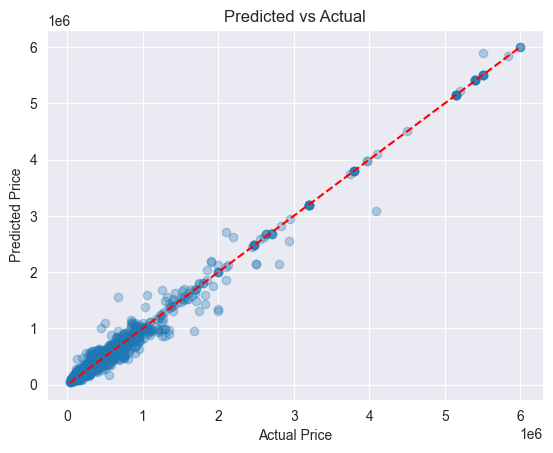

In [162]:
plt.scatter(y_test, y_pred_xgb_opt, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

## 10. Выводы

- Линейные модели дают MAE порядка ~XXX и R² ~0.72–0.75 — этого недостаточно для хорошего качества.
- Random Forest заметно улучшает качество, снижая MAE до ~80k и повышая R² до ~0.96.
- XGBoost и CatBoost дают ещё более высокое качество, особенно после подбора гиперпараметров.
- Лучшая модель (XGBoost + Optuna) показывает:
  - MAE ≈ 57k
  - RMSE ≈ 101k
  - R² ≈ 0.985

Это означает, что модель объясняет ~98.5% вариации цены автомобиля и в среднем ошибается на ~57k, что выглядит адекватно для диапазона цен в датасете.